## Задание: Классификация изображений: Cats vs Dogs

1. Обучить модель классификации изображение на 2 класса.
2. Исходные данные и валидация решения на kaggle в рамках контеста Cats vs Dogs.
3. Решения необходимо прислать в виде ipython-ноутбука с указанием значения метрики на Leaderboard. Задание засчитывается при значениях метрики Log Loss меньше 0.3. В случае нехватки ресурсов и сложностей с получением лосса 0.3 у модели VGG16 в этом задании можно использовать модель MobileNetV2.

In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import vgg16

## Загрузка данных 

In [60]:
import os ## нужен для автоматизированной работы с файлами
import glob ## найдет все пути, которые совпадают с тем, что указать внутри него
from random import shuffle ## для перемешивания выборок
import matplotlib.pyplot as plt

train_image = glob.glob('dogs-vs-cats-redux-kernels-edition/train/*.jpg')
test_image = glob.glob('dogs-vs-cats-redux-kernels-edition/test/*.jpg')

IMAGE_SIZE = (224,224)



In [93]:
len(train_image)

25000

### Функции

In [82]:
"""Функции для загрузки изображения"""

def load_image(path,size = IMAGE_SIZE):
    image = cv2.imread(path)[...,::-1] ## переворачиваем изображение - вместо BGR будет RGB
    image = cv2.resize(image,size) ## изменяем размер изображения на 224х224х3

    return vgg16.preprocess_input(image)

"""Генератор батчей"""

def files_generator(files,batch_size=32):
    batch_size = min(batch_size,len(files))
    ## запускаем генератор, который будет генерировать новые батчи после вызова функции не с начала, а каждый раз с того места, где остановился
    while True:
        shuffle(files)
        for k in range(len(files) // batch_size):
            i = k * batch_size ## позиция первой картинки в батче
            j = i + batch_size ## позиция последней картинки в батче
            if j > len(files): ## если позиция картинки в батче по подсчету выходит за фактическое количество файлов, то мы сдвигаемся влево на остаток от деления и берем эту картинку
                j = - j%len(files)
            x = np.array([load_image(path) for path in files[i:j]]) ## загружаем признаки в отдельный батч
            y = np.array([1 if os.path.basename(path).startswith('dog') else 0 for path in files[i:j]]) ## загружаем метки в батч
            
            yield (x,y)

"""Загрузка тестовых изображений"""
def predict_generator(files):
    while True:
        for path in files:
            img = load_image(path)
            img = np.expand_dims(img, axis=0)  # добавляем batch размерности (1, ...)
            yield (img,)

## Визуализация изображений

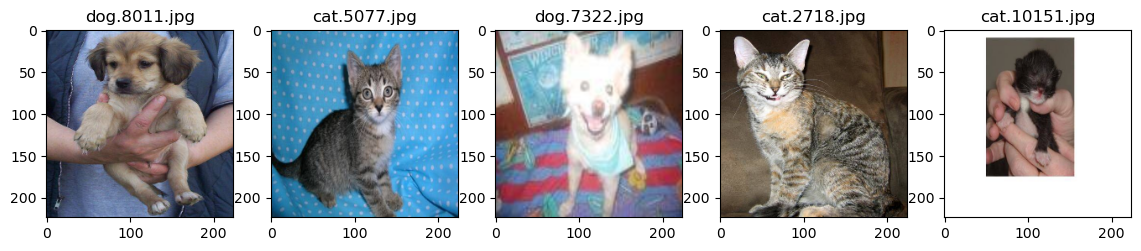

In [69]:
fig = plt.figure(figsize=(14,14))
for i, path in enumerate(train_image[:5],1):
    sub = fig.add_subplot(1,5,i)
    sub.set_title('%s'% path.split('/')[-1])
    img = cv2.imread(path)[...,::-1]
    img = cv2.resize(img,IMAGE_SIZE)
    plt.imshow(img)


##  Загрузка преодобученной модели vgg16

In [70]:
model = vgg16.VGG16(weights='imagenet',include_top=False,input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1064s 18us/step


In [71]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Добавляем слои

In [74]:
for layer in model.layers:
    layer.trainable = False ## все слои не будут обучаться

x = model.layers[-5].output ## берем только слои до последних 5
x = tf.keras.layers.Flatten()(x) ## добавляем преобразование в вектор
x = tf.keras.layers.Dense(1,activation='sigmoid',kernel_regularizer=tf.keras.regularizers.l1(1e-4))(x) ## добавляем полносвязынй слой
model_dog_cat = tf.keras.Model(inputs = model.input,outputs = x, name = 'dog_cat') ## создаем модель

## Компилируем модель и запускаем обучение

In [78]:
model_dog_cat.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

val_samples = 5
shuffle(train_image)

validation_data = next(files_generator(train_image[:val_samples],val_samples)) ## создаем валидационные батчи - следующие после обучающих
train_data = files_generator(train_image[val_samples:]) ## создаем обучающие батчи

model_dog_cat.fit(train_data,steps_per_epoch=10,epochs=100,validation_data=validation_data) ## steps_per_epoch=10 - сколько раз будет вызываться генератор за эпоху


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.5351 - loss: 689.6334 - val_accuracy: 0.2000 - val_loss: 1583.1643
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.7099 - loss: 335.5661 - val_accuracy: 0.6000 - val_loss: 471.9444
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.8182 - loss: 117.7230 - val_accuracy: 0.8000 - val_loss: 71.0969
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.8269 - loss: 159.1056 - val_accuracy: 0.8000 - val_loss: 189.2197
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8653 - loss: 104.5971 - val_accuracy: 0.8000 - val_loss: 109.1962
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9125 - loss: 34.6865 - val_accuracy: 0.6000 - val_loss: 249.4047
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.8821 - loss: 68.0283 - val_accuracy: 0.8000 - val_loss: 7.6502
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9013 - loss: 34.4966 -

## Предсказания на тестовой выборке

In [83]:
predict = model_dog_cat.predict(predict_generator(test_image),steps=len(test_image))

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 1583s 127ms/step


## Визуализация предсказаний

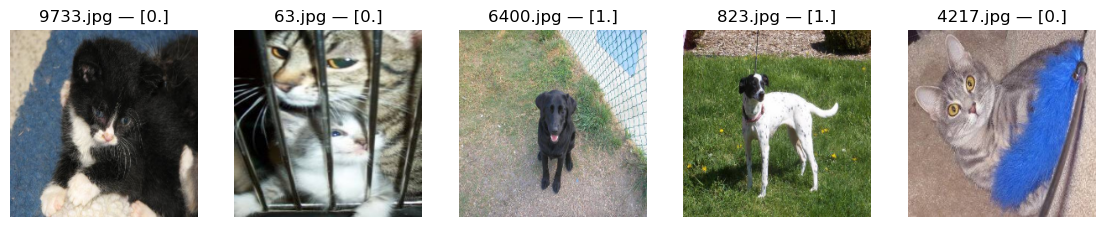

In [87]:
fig = plt.figure(figsize=(14,14))
for i, (img_path, pred) in enumerate(zip(test_image[:5], predict[:5]), 1):
    sub = fig.add_subplot(1, 5, i)
    sub.set_title(f"{os.path.basename(img_path)} — {pred}")
    img = cv2.imread(img_path)[..., ::-1]
    img = cv2.resize(img, IMAGE_SIZE)
    sub.imshow(img)
    sub.axis('off')

## Выводы

В целом, модель vgg16, предуобученная на датасете imagenet, дает достаточно высокий результат: ошибка на обучащей выборке log_loss = 27, точность accuracy = 94%, ошибка на валидационной выборке = 0,15. К сожалению, на данной тестовой выборке нельзя посмотреть такие метрики как полнота recall и точность precision, так как фотографии не размечены, но можно сделать вывод, что модель ошибается в каждой 17 картинке (исходя из обучающей выборки)